In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import time
import copy
import itertools

# configs
DATASET_PATH = 'merged_dataset(1).csv'
MODEL_SAVE_PATH = 'best_bilstm_model_v2.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [2]:
print("\n" + "="*60)
print("Step 1: Loading and Splitting Data (New Manual Group Split)")
print("="*60)

try:
    df = pd.read_csv(DATASET_PATH)
    if not all(col in df.columns for col in ['text', 'label', 'source']):
        raise ValueError("CSV must contain 'text', 'label', and 'source' columns.")
except FileNotFoundError:
    print(f"Error: Dataset not found at '{DATASET_PATH}'.")
    exit()

# shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# source groups
train_sources = [
    'HC3_reddit_eli5',
    'HC3_finance',
    'DAIGT_v2_Distance learning',
    'DAIGT_v2_Seeking multiple opinions',
    'HC3_open_qa'
]

val_sources = [
    'DAIGT_v2_Car-free cities',
    'DAIGT_v2_Does the electoral college work?',
    'DAIGT_v2_Facial action coding system',
    'DAIGT_v2_Mandatory extracurricular activities',
    'DAIGT_v2_Summer projects',
    'HC3_medicine',
    'DAIGT_v2_Driverless cars',
    'DAIGT_v2_Exploring Venus'
]

test_sources = [
    'DAIGT_v2_Cell phones at school',
    'DAIGT_v2_Grades for extracurricular activities',
    'DAIGT_v2_Community service',
    'DAIGT_v2_"A Cowboy Who Rode the Waves"',
    'DAIGT_v2_The Face on Mars',
    'HC3_wiki_csai',
    'DAIGT_v2_Phones and driving'
]


# Split DataFrames
train_df = df[df['source'].isin(train_sources)]
val_df = df[df['source'].isin(val_sources)]
test_df = df[df['source'].isin(test_sources)]

# Extract Text and Labels
X_train_raw, y_train = train_df['text'].astype(str).values, train_df['label'].values
X_val_raw, y_val = val_df['text'].astype(str).values, val_df['label'].values
X_test_raw, y_test = test_df['text'].astype(str).values, test_df['label'].values

print(f"Total dataset size: {len(df)}")
print(f"Training set size:   {len(X_train_raw)} ({len(X_train_raw)/len(df):.1%})")
print(f"Validation set size: {len(X_val_raw)} ({len(X_val_raw)/len(df):.1%})")
print(f"Test set size:       {len(X_test_raw)} ({len(X_test_raw)/len(df):.1%})")


Step 1: Loading and Splitting Data (New Manual Group Split)
Total dataset size: 124195
Training set size:   85897 (69.2%)
Validation set size: 24987 (20.1%)
Test set size:       13311 (10.7%)


In [3]:
print("\n" + "="*60)
print("Step 2: Preprocessing (Building Vocabulary & Padding)")
print("="*60)

class TextTokenizer:
    def __init__(self, max_words=30000, max_len=600): #30000 covers 97.65% of all word occurrence, 95% of texts have 582 words or fewer.
        self.max_words = max_words
        self.max_len = max_len
        self.word_index = {}
        self.vocab_size = 0
        
    def fit(self, texts):
        counter = Counter()
        for text in texts:
            words = text.lower().split()
            counter.update(words)
        most_common = counter.most_common(self.max_words - 1)
        self.word_index = {word: i+1 for i, (word, count) in enumerate(most_common)}
        self.vocab_size = len(self.word_index) + 1
        print(f"Vocabulary size: {self.vocab_size}")
        
    def transform(self, texts):
        sequences = []
        for text in texts:
            words = text.lower().split()
            seq = [self.word_index.get(w, 0) for w in words]
            if len(seq) > self.max_len:
                seq = seq[:self.max_len]
            seq = seq + [0] * (self.max_len - len(seq))
            sequences.append(seq)
        return np.array(sequences)

tokenizer = TextTokenizer(max_words=30000, max_len=600)
tokenizer.fit(X_train_raw)
X_train_seq = tokenizer.transform(X_train_raw)
X_val_seq = tokenizer.transform(X_val_raw)
X_test_seq = tokenizer.transform(X_test_raw)

train_data = TensorDataset(torch.LongTensor(X_train_seq), torch.FloatTensor(y_train))
val_data = TensorDataset(torch.LongTensor(X_val_seq), torch.FloatTensor(y_val))
test_data = TensorDataset(torch.LongTensor(X_test_seq), torch.FloatTensor(y_test))



Step 2: Preprocessing (Building Vocabulary & Padding)
Vocabulary size: 30000


In [4]:
# model definition of BiLSTM

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        embedded = self.embedding(x) 
        lstm_out, _ = self.lstm(embedded)
        final_feature_map = lstm_out[:, -1, :] 
        x = self.dropout(final_feature_map)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
# Training Helper Function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15, patience=3):
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
                
    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc


In [8]:
print("\n" + "="*60)
print("Step 5: Manual Grid Search for Hyperparameters with Timing")
print("="*60)

param_grid = {
    'lstm_units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.5],
    'batch_size': [128, 256],
    'learning_rate': [0.0005, 0.001]
}
best_overall_acc, best_config, best_model_final, best_history_final = 0.0, {}, None, None


results_log = []
grid_search_start_time = time.time()

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

for i, params in enumerate(combinations):
    print(f"\n--- Training Config {i+1}/{len(combinations)}: {params} ---")
    train_loader = DataLoader(train_data, batch_size=params['batch_size'], shuffle=True)
    val_loader = DataLoader(val_data, batch_size=params['batch_size'])
    model = BiLSTMClassifier(
        vocab_size=tokenizer.vocab_size, embedding_dim=128, 
        hidden_dim=params['lstm_units'], dropout_rate=params['dropout_rate']
    ).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'])
    
    # training time
    config_train_start_time = time.time()
    trained_model, history, val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=15, patience=3
    )
    config_train_end_time = time.time()
    training_duration = config_train_end_time - config_train_start_time

    # inference time on validation
    inference_start_time = time.time()
    trained_model.eval()
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)
            _ = trained_model(inputs)
    inference_end_time = time.time()
    inference_duration = inference_end_time - inference_start_time
    
    print(f"Config {i+1} Summary: Val Acc: {val_acc:.4f} | Train Time: {training_duration:.2f}s | Inference Time: {inference_duration:.2f}s")
    
    results_log.append({
        'config_id': i + 1,
        'params': str(params),
        'val_accuracy': val_acc,
        'training_time_s': training_duration,
        'inference_time_s': inference_duration
    })

    if val_acc > best_overall_acc:
        best_overall_acc = val_acc
        best_config = params
        best_model_final = trained_model
        best_history_final = history
        print(f"-> New Best Model found!")

grid_search_end_time = time.time()
total_duration = grid_search_end_time - grid_search_start_time

print("\n" + "="*60)
print(f"Grid Search Complete in {total_duration:.2f} seconds.")
print(f"Best Configuration: {best_config} | Best Val Acc: {best_overall_acc:.4f}")
torch.save(best_model_final.state_dict(), MODEL_SAVE_PATH)


print("\n--- Detailed Grid Search Results ---")
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(by='val_accuracy', ascending=False)
print(results_df)



Step 5: Manual Grid Search for Hyperparameters with Timing

--- Training Config 1/36: {'lstm_units': 64, 'dropout_rate': 0.2, 'batch_size': 128, 'learning_rate': 0.0005} ---
Epoch 1/15 | Train Loss: 0.5935 Acc: 0.6615 | Val Loss: 0.8047 Acc: 0.6397
Epoch 2/15 | Train Loss: 0.1412 Acc: 0.9540 | Val Loss: 0.4344 Acc: 0.8225
Epoch 3/15 | Train Loss: 0.0680 Acc: 0.9771 | Val Loss: 0.7688 Acc: 0.7294
Epoch 4/15 | Train Loss: 0.0392 Acc: 0.9875 | Val Loss: 0.6713 Acc: 0.8233
Epoch 5/15 | Train Loss: 0.0247 Acc: 0.9926 | Val Loss: 0.6747 Acc: 0.8172
Epoch 6/15 | Train Loss: 0.0212 Acc: 0.9937 | Val Loss: 0.7601 Acc: 0.8301
Epoch 7/15 | Train Loss: 0.0164 Acc: 0.9955 | Val Loss: 1.1624 Acc: 0.7485
Epoch 8/15 | Train Loss: 0.0112 Acc: 0.9969 | Val Loss: 0.9017 Acc: 0.8123
Epoch 9/15 | Train Loss: 0.0087 Acc: 0.9978 | Val Loss: 1.2284 Acc: 0.7678
Early stopping triggered.
Config 1 Summary: Val Acc: 0.8301 | Train Time: 36.27s | Inference Time: 0.24s
-> New Best Model found!

--- Training Config

In [11]:
# ==========================================
# 6. Final Evaluation on Test Set with Timing
# ==========================================
print("\n" + "="*60)
print("Step 6: Evaluation on Unseen Test Set")
print("="*60)

test_loader = DataLoader(test_data, batch_size=best_config['batch_size'])
best_model_final.eval()
y_true, y_pred_probs = [], []

# final inference time
final_inference_start_time = time.time()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model_final(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_pred_probs.extend(probs)
        y_true.extend(labels.numpy())
final_inference_end_time = time.time()
final_inference_duration = final_inference_end_time - final_inference_start_time

print(f"Inference on {len(y_true)} test samples took {final_inference_duration:.4f} seconds.")

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).ravel()
y_pred_class = (y_pred_probs > 0.5).astype(int)

test_acc = accuracy_score(y_true, y_pred_class)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_class, target_names=['Human', 'AI Generated']))


Step 6: Evaluation on Unseen Test Set
Inference on 13311 test samples took 1.2097 seconds.

Final Test Accuracy: 0.8886

Classification Report:
              precision    recall  f1-score   support

       Human       0.93      0.91      0.92      9717
AI Generated       0.78      0.82      0.80      3594

    accuracy                           0.89     13311
   macro avg       0.86      0.87      0.86     13311
weighted avg       0.89      0.89      0.89     13311



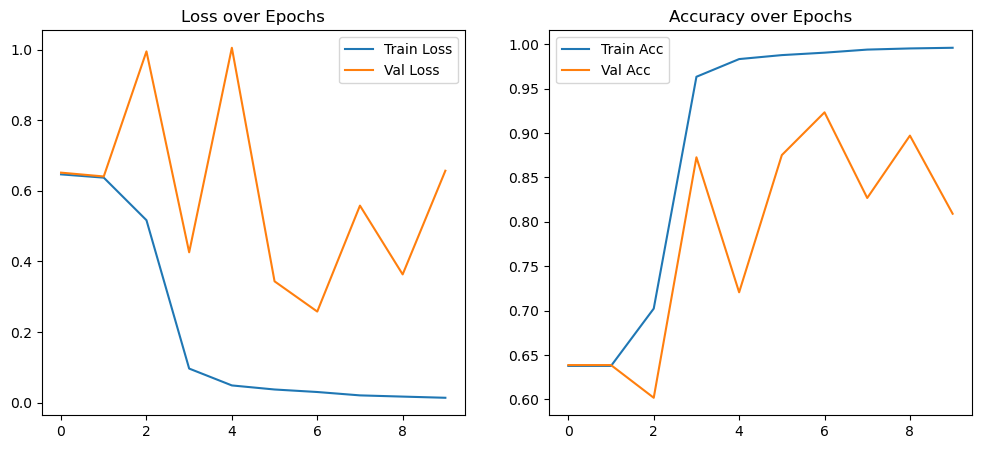

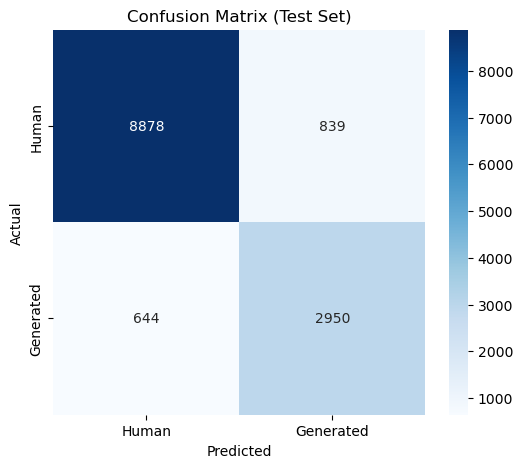

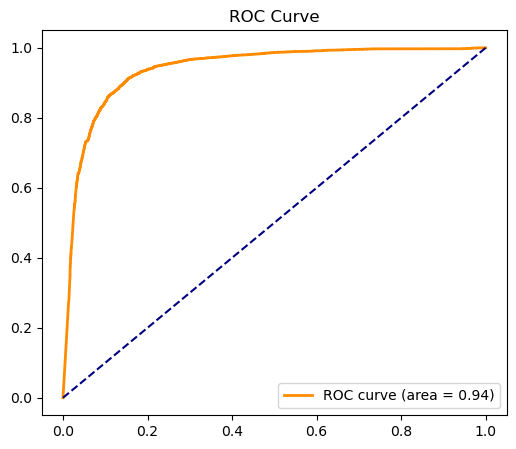

In [10]:
# training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history_final['train_loss'], label='Train Loss')
plt.plot(best_history_final['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history_final['train_acc'], label='Train Acc')
plt.plot(best_history_final['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

cm = confusion_matrix(y_true, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'Generated'], yticklabels=['Human', 'Generated'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

**Comments to the graph**, the loss and accuracy of validation flucutates, maybe should put the learning smaller? But the best HP config has lr = 0.001. 
<br>Also early stopping might cause local optima because of fluctuation, need to think on how to find out when to stop.